In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Завантаження й огляд даних
# MNIST - це чорно-білі картинки рукописних цифр 28x28 пікселів. keras віддає їх уже поділеними на
# train і test. y - це правильна цифра від 0 до 9.
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
# Значення пікселів - цілі числа від 0 до 255 (яскравість). Датасет готовий, пропусків тут не буває.
print("тип:", x_train_full.dtype, "| мін:", x_train_full.min(), "| макс:", x_train_full.max())

тип: uint8 | мін: 0 | макс: 255


In [4]:
# Баланс класів у train - скільки прикладів кожної цифри. Приблизно по 6000 на цифру, тобто класи
# рівні.
pd.Series(y_train_full).value_counts().sort_index()

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

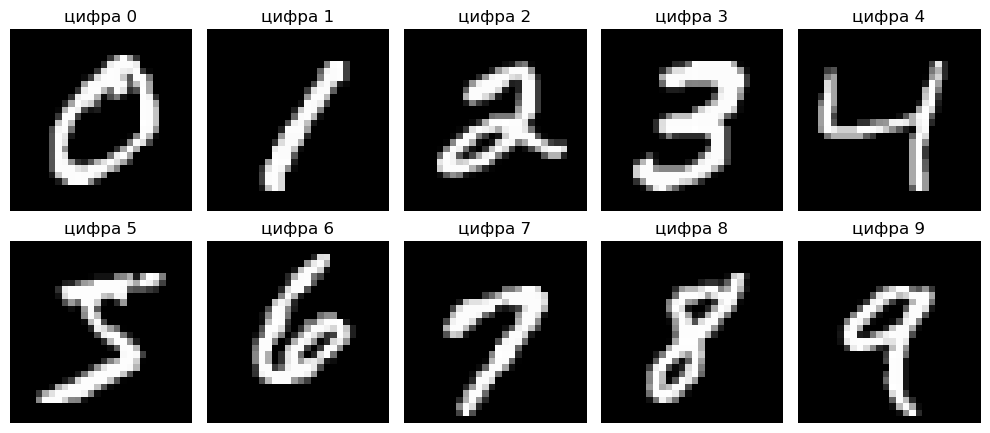

In [5]:
# Дивимось по одному прикладу кожної цифри, щоб побачити, з чим працюємо.
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in enumerate(axes.ravel()):
    idx = np.argmax(y_train_full == digit)
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(f"цифра {digit}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# Крок 2. Підготовка даних
# Два прості кроки. Перший - нормалізація: ділимо пікселі на 255, щоб значення були від 0 до 1
# (мережі легше вчитись на малих числах). Другий - розплющуємо кожну картинку 28x28 у вектор 784, бо
# Dense-шар приймає плоский вектор, а не двовимірну картинку.
x_train_full_flat = (x_train_full / 255.0).reshape(-1, 28 * 28).astype("float32")
x_test_flat = (x_test / 255.0).reshape(-1, 28 * 28).astype("float32")
x_train_full_flat.shape, x_test_flat.shape

((60000, 784), (10000, 784))

In [7]:
# Виділяємо валідацію з train: останні 10000 прикладів - на валідацію, решта 50000 - на навчання.
# Валідація потрібна, щоб під час тренування стежити, чи не починає мережа перенавчатись.
x_val, y_val = x_train_full_flat[50000:], y_train_full[50000:]
x_train, y_train = x_train_full_flat[:50000], y_train_full[:50000]
x_train.shape, x_val.shape, x_test_flat.shape

((50000, 784), (10000, 784), (10000, 784))

In [8]:
# Перевіряємо, що у валідації всі класи представлені більш-менш рівно (train перемішаний, тож поділ
# простим зрізом не має дати перекосу).
pd.Series(y_val).value_counts().sort_index()

0     991
1    1064
2     990
3    1030
4     983
5     915
6     967
7    1090
8    1009
9     961
Name: count, dtype: int64

In [9]:
# Крок 3. Базова модель
# Найпростіша повнозв'язна мережа: один прихований шар зі 128 нейронів (relu) і вихідний шар на 10
# нейронів (по одному на цифру) з softmax, що дає ймовірності класів. Вхід - вектор 784. compile
# задає, як мережа вчитиметься: optimizer adam оновлює ваги, loss для цілих міток
# (sparse_categorical_crossentropy), і метрика accuracy, щоб бачити частку правильних відповідей.
model = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Крок 4. Тренування
# Тренуємо мережу на train, а на кожній епосі перевіряємо якість на валідації. Одна епоха - це один
# повний прохід по всіх тренувальних прикладах. batch_size - скільки прикладів мережа дивиться за
# один крок оновлення ваг. history запам'ятає loss і accuracy по епохах, щоб потім побудувати криві
# навчання.
history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                    epochs=20, batch_size=128, verbose=2)

Epoch 1/20


391/391 - 1s - 2ms/step - accuracy: 0.8914 - loss: 0.3908 - val_accuracy: 0.9440 - val_loss: 0.2002


Epoch 2/20


391/391 - 1s - 1ms/step - accuracy: 0.9475 - loss: 0.1844 - val_accuracy: 0.9580 - val_loss: 0.1507


Epoch 3/20


...

391/391 - 0s - 857us/step - accuracy: 0.9993 - loss: 0.0090 - val_accuracy: 0.9750 - val_loss: 0.0889


Epoch 19/20


391/391 - 0s - 875us/step - accuracy: 0.9994 - loss: 0.0075 - val_accuracy: 0.9750 - val_loss: 0.0881


Epoch 20/20


391/391 - 0s - 755us/step - accuracy: 0.9995 - loss: 0.0063 - val_accuracy: 0.9750 - val_loss: 0.0914


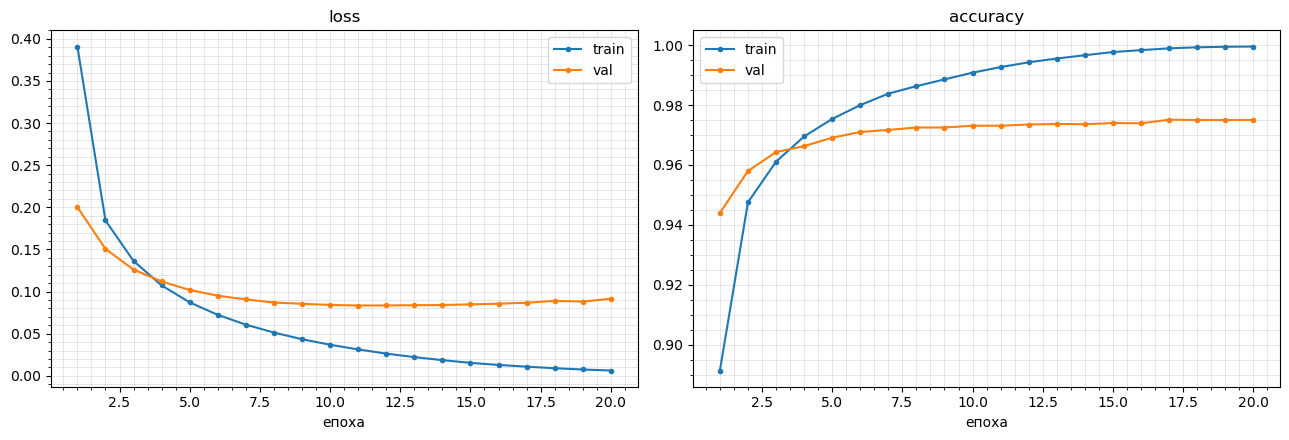

In [11]:
# Крок 5. Криві навчання
# Малюємо, як мінялись loss і accuracy по епохах на train і на валідації. Розходження між кривими
# показує перенавчання: train далі покращується, а валідація застигає. Видно, що val_loss спочатку
# падає, а потім розвертається вгору - з цього моменту мережа вже переучується.
h = history.history
epochs_range = range(1, len(h["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(epochs_range, h["loss"], marker="o", ms=3, label="train")
axes[0].plot(epochs_range, h["val_loss"], marker="o", ms=3, label="val")
axes[0].set_title("loss")
axes[0].set_xlabel("епоха")
axes[0].legend()
axes[1].plot(epochs_range, h["accuracy"], marker="o", ms=3, label="train")
axes[1].plot(epochs_range, h["val_accuracy"], marker="o", ms=3, label="val")
axes[1].set_title("accuracy")
axes[1].set_xlabel("епоха")
axes[1].legend()
plt.tight_layout()
plt.show()

In [12]:
# Крок 6. Рання зупинка (EarlyStopping)
# На кривих вище видно, що після ~13 епохи мережа переучується. EarlyStopping стежить за val_loss і
# зупиняє навчання, коли той перестав покращуватись, та повертає ваги найкращої епохи. Так ми беремо
# не перенавчану модель, а найкращу. Тренуємо заново таку саму мережу, але вже з цим механізмом.
keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history_es = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                       epochs=50, batch_size=128, verbose=0, callbacks=[early])
best_epoch = int(np.argmin(history_es.history["val_loss"])) + 1
print(f"навчання зупинилось на епосі {len(history_es.history['loss'])}, найкраща епоха: {best_epoch}")
print(f"найкращий val_loss: {min(history_es.history['val_loss']):.4f}")

навчання зупинилось на епосі 13, найкраща епоха: 10
найкращий val_loss: 0.0857


In [13]:
# Крок 7. Оцінка на тестовому наборі
# Перевіряємо на тесті модель із ранньою зупинкою - на даних, яких вона не бачила ні під час
# тренування, ні на валідації. Це чесна оцінка якості.
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"test accuracy: {test_acc:.4f} | test loss: {test_loss:.4f}")

test accuracy: 0.9770 | test loss: 0.0765


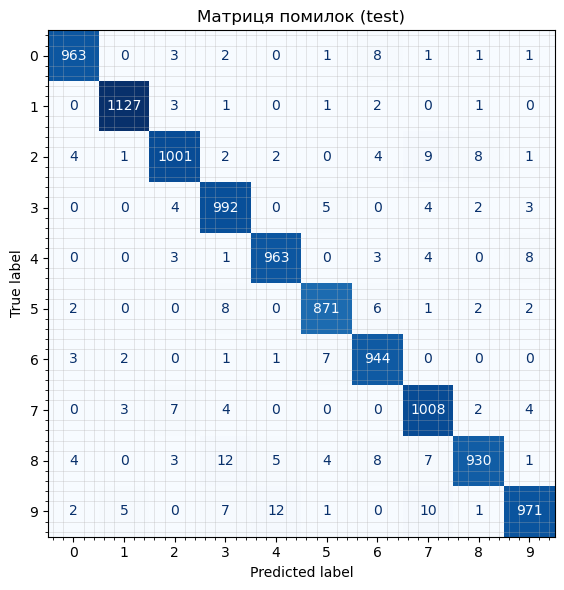

In [14]:
# Матриця помилок: по діагоналі - правильні відповіді, поза діагоналлю - де мережа плутає. Значення
# на діагоналі великі, помилок мало. Найпомітніші плутанини - між схожими за формою цифрами
# (наприклад 4 і 9, 3 і 5).
y_pred = model.predict(x_test_flat, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues", colorbar=False)
ax.grid(False)
plt.title("Матриця помилок (test)")
plt.tight_layout()
plt.show()

помилок: 230 з 10000


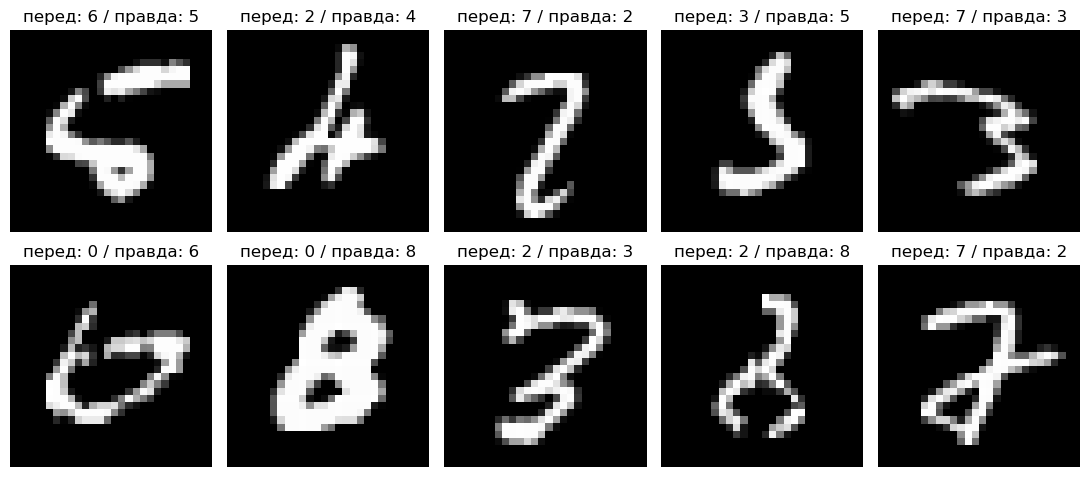

In [15]:
# Дивимось кілька прикладів, де мережа помилилась: над картинкою - що вона передбачила і яка
# правильна відповідь. Часто це справді неохайно написані цифри, які й людині важко розібрати.
wrong = np.where(y_pred != y_test)[0]
print(f"помилок: {len(wrong)} з {len(y_test)}")
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, idx in zip(axes.ravel(), wrong[:10]):
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"перед: {y_pred[idx]} / правда: {y_test[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Крок 8. Порівняння кількох Dense-архітектур
# Пробуємо різні варіанти: ширший шар, глибша мережа і dropout. Dropout - це не окремий тип мережі,
# а просто прийом проти перенавчання: під час навчання він випадково вимикає частину нейронів.
# Дивимось, як варіанти впливають на test accuracy і на розрив між train і val (більший розрив -
# сильніше перенавчання).
def build_train(hidden, dropout=0.0, epochs=15):
    keras.utils.set_random_seed(42)
    layers = [keras.Input(shape=(784,))]
    for units in hidden:
        layers.append(keras.layers.Dense(units, activation="relu"))
        if dropout:
            layers.append(keras.layers.Dropout(dropout))
    layers.append(keras.layers.Dense(10, activation="softmax"))
    m = keras.Sequential(layers)
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(x_train, y_train, validation_data=(x_val, y_val),
                 epochs=epochs, batch_size=128, verbose=0)
    tr = hist.history["accuracy"][-1]
    va = hist.history["val_accuracy"][-1]
    te = m.evaluate(x_test_flat, y_test, verbose=0)[1]
    return m.count_params(), tr, va, te

configs = [
    ("128", [128], 0.0),
    ("512", [512], 0.0),
    ("256+128", [256, 128], 0.0),
    ("256 +drop0.3", [256], 0.3),
    ("256+128 +drop0.3", [256, 128], 0.3),
]
rows = []
for name, hidden, drop in configs:
    params, tr, va, te = build_train(hidden, drop)
    rows.append({"модель": name, "параметри": params, "train_acc": round(tr, 4),
                 "val_acc": round(va, 4), "test_acc": round(te, 4),
                 "розрив_train_val": round(tr - va, 4)})
results = pd.DataFrame(rows)
results

,модель,параметри,train_acc,val_acc,test_acc,розрив_train_val
0,128,101770,0.9981,0.9767,0.9775,0.0214
1,512,407050,0.9988,0.9799,0.9819,0.0189
2,256+128,235146,0.9971,0.9783,0.9787,0.0188
3,256 +drop0.3,203530,0.9912,0.9813,0.9817,0.0099
4,256+128 +drop0.3,235146,0.9875,0.9828,0.9804,0.0047


In [17]:
# Найкращий баланс - 256 з dropout: test accuracy майже як у широкої 512, але розрив train-val у ~2
# рази менший. Ширший шар (512) дає трохи вищу точність ціною вчетверо більшої кількості параметрів.
# Dropout помітно зменшує розрив train-val (з 0.021 до 0.005), тобто реально стримує перенавчання.
results.sort_values("test_acc", ascending=False)

,модель,параметри,train_acc,val_acc,test_acc,розрив_train_val
1,512,407050,0.9988,0.9799,0.9819,0.0189
3,256 +drop0.3,203530,0.9912,0.9813,0.9817,0.0099
4,256+128 +drop0.3,235146,0.9875,0.9828,0.9804,0.0047
2,256+128,235146,0.9971,0.9783,0.9787,0.0188
0,128,101770,0.9981,0.9767,0.9775,0.0214


In [18]:
# Висновки
# - MNIST - 70000 картинок цифр 28x28. Пікселі нормалізували (0-1) і розплющили у вектор 784, бо
#   Dense-шар приймає плоский вектор. Класи рівні, тому балансування не потрібне.
# - Базова мережа (один Dense 128 + вихід на 10) дає test accuracy ~97.7%. Навіть така проста
#   повнозв'язна мережа впевнено розпізнає рукописні цифри.
# - Криві навчання показали перенавчання: train доходить до ~100%, а val застигає ~97.7%, і val_loss
#   після ~13 епохи починає рости.
# - Перенавчання прибрали ранньою зупинкою (EarlyStopping): беремо ваги найкращої епохи замість
#   перенавченої моделі й тренуємо менше епох.
# - Помилок на тесті небагато (близько 230 з 10000), переважно на неохайно написаних цифрах;
#   найчастіші плутанини між схожими формами (7 і 2, 3 і 5, 4 і 9).
# - Порівняння архітектур: ширший шар дає трохи вищу точність, а dropout помітно зменшує
#   перенавчання (розрив train-val падає з 0.021 до 0.005). Найкращий баланс - 256 нейронів з
#   dropout.
# - Підсумок: лише на Dense-шарах виходить ~98% на MNIST. Вищу точність зазвичай дають згорткові
#   мережі, а тут ми використали лише Dense-шари.